In [19]:
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt
import pandas as pd
import time

### Exercise 1

Change the number of hidden units num_hiddens and plot how its number affects the accuracy of the model. What is the best value of this hyperparameter?

In [2]:
data = d2l.FashionMNIST(batch_size=256)

In [7]:
class MLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )

In [8]:
# disable D2L plotting
class MLPNoPlot(MLP):
    def plot(self, key, value, train):
        pass

In [9]:
def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            pred = y_hat.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total

num_hiddens =   16, val_acc = 0.8347
num_hiddens =   32, val_acc = 0.8360
num_hiddens =   64, val_acc = 0.8485
num_hiddens =  128, val_acc = 0.8539
num_hiddens =  256, val_acc = 0.8559
num_hiddens =  512, val_acc = 0.8488
num_hiddens = 1024, val_acc = 0.8049


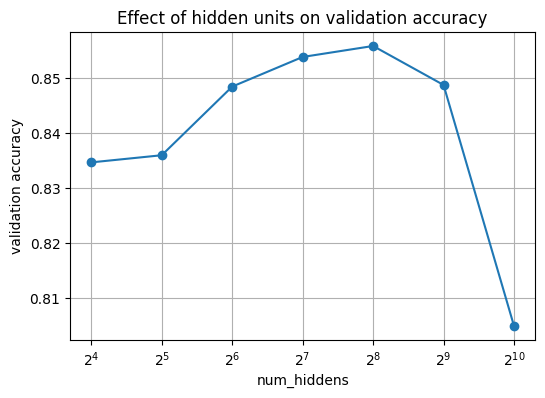

Best num_hiddens = 256
Best validation accuracy = 0.8559


In [10]:
# store results
hidden_list = [16, 32, 64, 128, 256, 512, 1024]
val_accs = []

for h in hidden_list:
    model = MLPNoPlot(num_outputs=10, num_hiddens=h, lr=0.1)
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)

    val_acc = evaluate_accuracy(model, data.val_dataloader())
    val_accs.append(val_acc)
    print(f"num_hiddens = {h:4d}, val_acc = {val_acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(hidden_list, val_accs, marker='o')
plt.xlabel('num_hiddens')
plt.ylabel('validation accuracy')
plt.title('Effect of hidden units on validation accuracy')
plt.xscale('log', base=2)
plt.grid(True)
plt.show()

best_h = hidden_list[val_accs.index(max(val_accs))]
print("Best num_hiddens =", best_h)
print("Best validation accuracy =", max(val_accs))

### Exercise 2

Try adding a hidden layer to see how it affects the results.

In [ ]:
class MLP1(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )

# disable D2L plotting
class MLP1NoPlot(MLP1):
    def plot(self, key, value, train):
        pass


In [7]:
class MLP2(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens1, num_hiddens2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens1),
            nn.ReLU(),
            nn.LazyLinear(num_hiddens2),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )

# disable D2L plotting
class MLP2NoPlot(MLP2):
    def plot(self, key, value, train):
        pass

In [8]:
def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            pred = y_hat.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return correct / total

# one hidden layer
model1 = MLP1NoPlot(num_outputs=10, num_hiddens=256, lr=0.1)
trainer1 = d2l.Trainer(max_epochs=10)
trainer1.fit(model1, data)
acc1 = evaluate_accuracy(model1, data.val_dataloader())

# two hidden layers
model2 = MLP2NoPlot(num_outputs=10, num_hiddens1=256, num_hiddens2=256, lr=0.1)
trainer2 = d2l.Trainer(max_epochs=10)
trainer2.fit(model2, data)
acc2 = evaluate_accuracy(model2, data.val_dataloader())

print(f"1 hidden layer val acc: {acc1:.4f}")
print(f"2 hidden layers val acc: {acc2:.4f}")

/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


1 hidden layer val acc: 0.8492
2 hidden layers val acc: 0.8461


### Exercise 3

Why is it a bad idea to insert a hidden layer with a single neuron? What could go wrong?

Inserting a hidden layer with a single neuron creates a severe information bottleneck. The layer must compress the entire input vector into a single scalar before producing the output. As a result, the output can only depend on a one-dimensional projection of the input. This drastically limits the expressive power of the network.

### Exercise 4

How does changing the learning rate alter your results? With all other parameters fixed, which learning rate gives you the best results?

In [9]:
class MLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )

In [10]:
# disable D2L plotting
class MLPNoPlot(MLP):
    def plot(self, key, value, train):
        pass

In [11]:
def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            pred = y_hat.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total

lr = 0.001, val_acc = 0.6534
lr = 0.010, val_acc = 0.8011
lr = 0.030, val_acc = 0.8278
lr = 0.100, val_acc = 0.8463
lr = 0.300, val_acc = 0.8646
lr = 1.000, val_acc = 0.1554


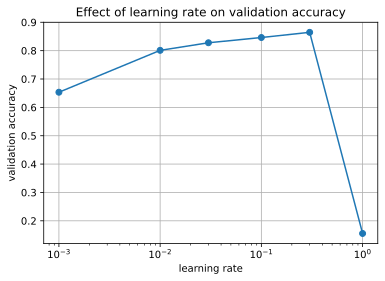

Best learning rate = 0.3
Best validation accuracy = 0.8646


In [12]:
lr_list = [0.001, 0.01, 0.03, 0.1, 0.3, 1.0]
val_accs = []

for lr in lr_list:
    model = MLPNoPlot(num_outputs=10, num_hiddens=256, lr=lr)
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)

    val_acc = evaluate_accuracy(model, data.val_dataloader())
    val_accs.append(val_acc)
    print(f"lr = {lr:.3f}, val_acc = {val_acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(lr_list, val_accs, marker='o')
plt.xscale('log')
plt.xlabel('learning rate')
plt.ylabel('validation accuracy')
plt.title('Effect of learning rate on validation accuracy')
plt.grid(True)
plt.show()

best_lr = lr_list[val_accs.index(max(val_accs))]
print("Best learning rate =", best_lr)
print("Best validation accuracy =", max(val_accs))

### Exercise 5

Let's optimize over all hyperparameters jointly, i.e., learning rate, number of epochs, number of hidden layers, and number of hidden units per layer. What is the best result you can get by optimizing over all of them?


In [14]:
class FlexibleMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, num_layers, lr):
        super().__init__()
        self.save_hyperparameters()

        layers = [nn.Flatten()]
        for _ in range(num_layers):
            layers.append(nn.LazyLinear(num_hiddens))
            layers.append(nn.ReLU())
        layers.append(nn.LazyLinear(num_outputs))

        self.net = nn.Sequential(*layers)

In [15]:
# disable D2L plotting
class FlexibleMLPNoPlot(FlexibleMLP):
    def plot(self, key, value, train):
        pass

In [16]:
def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            pred = y_hat.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total

In [17]:
lrs = [0.03, 0.1, 0.3]
epochs_list = [10, 20]
num_layers_list = [1, 2, 3]
hidden_units_list = [64, 128, 256]

results = []
best_acc = -1
best_config = None
best_model = None

for lr in lrs:
    for epochs in epochs_list:
        for num_layers in num_layers_list:
            for num_hiddens in hidden_units_list:
                print(f"Training: lr={lr}, epochs={epochs}, "
                      f"layers={num_layers}, hidden={num_hiddens}")

                model = FlexibleMLPNoPlot(
                    num_outputs=10,
                    num_hiddens=num_hiddens,
                    num_layers=num_layers,
                    lr=lr
                )
                trainer = d2l.Trainer(max_epochs=epochs)
                trainer.fit(model, data)

                val_acc = evaluate_accuracy(model, data.val_dataloader())
                results.append({
                    'lr': lr,
                    'epochs': epochs,
                    'num_layers': num_layers,
                    'num_hiddens': num_hiddens,
                    'val_acc': val_acc
                })

                print(f"Validation accuracy: {val_acc:.4f}\n")

                if val_acc > best_acc:
                    best_acc = val_acc
                    best_config = (lr, epochs, num_layers, num_hiddens)
                    best_model = model

print("Best validation accuracy:", best_acc)
print("Best config:")
print(f"lr={best_config[0]}, epochs={best_config[1]}, "
      f"num_layers={best_config[2]}, num_hiddens={best_config[3]}")

Training: lr=0.03, epochs=10, layers=1, hidden=64
Validation accuracy: 0.8215

Training: lr=0.03, epochs=10, layers=1, hidden=128
Validation accuracy: 0.8264

Training: lr=0.03, epochs=10, layers=1, hidden=256
Validation accuracy: 0.8307

Training: lr=0.03, epochs=10, layers=2, hidden=64
Validation accuracy: 0.8265

Training: lr=0.03, epochs=10, layers=2, hidden=128
Validation accuracy: 0.8233

Training: lr=0.03, epochs=10, layers=2, hidden=256
Validation accuracy: 0.8149

Training: lr=0.03, epochs=10, layers=3, hidden=64
Validation accuracy: 0.8155

Training: lr=0.03, epochs=10, layers=3, hidden=128
Validation accuracy: 0.8230

Training: lr=0.03, epochs=10, layers=3, hidden=256
Validation accuracy: 0.8073

Training: lr=0.03, epochs=20, layers=1, hidden=64
Validation accuracy: 0.8437

Training: lr=0.03, epochs=20, layers=1, hidden=128
Validation accuracy: 0.8440

Training: lr=0.03, epochs=20, layers=1, hidden=256
Validation accuracy: 0.8440

Training: lr=0.03, epochs=20, layers=2, hidd

In [18]:
import pandas as pd

df = pd.DataFrame(results)
df = df.sort_values('val_acc', ascending=False)
df.head(10)

,lr,epochs,num_layers,num_hiddens,val_acc
47,0.3,20,1,256,0.8857
43,0.3,10,3,128,0.8751
50,0.3,20,2,256,0.8747
32,0.1,20,2,256,0.8739
34,0.1,20,3,128,0.8727
29,0.1,20,1,256,0.8627
52,0.3,20,3,128,0.8611
53,0.3,20,3,256,0.8608
28,0.1,20,1,128,0.8607
37,0.3,10,1,128,0.8590


### Exercise 7

Measure the speed of tensor-matrix multiplications for well-aligned and misaligned matrices. For instance, test for matrices with dimension 1024, 1025, 1026, 1028, and 1032. Determine the memory bus width of your CPU.

In [22]:
# use CPU
device = torch.device("cpu")

sizes = [1024, 1025, 1026, 1028, 1032]
results = []

# warm-up
for _ in range(3):
    A = torch.randn(512, 512, device=device)
    B = torch.randn(512, 512, device=device)
    C = A @ B

for n in sizes:
    A = torch.randn(n, n, device=device)
    B = torch.randn(n, n, device=device)

    # warm-up for this size
    for _ in range(3):
        C = A @ B

    num_runs = 10
    start = time.perf_counter()
    for _ in range(num_runs):
        C = A @ B
    end = time.perf_counter()

    avg_time = (end - start) / num_runs
    flops = 2 * (n ** 3)   # rough FLOP count for matmul
    gflops = flops / avg_time / 1e9

    results.append({
        "n": n,
        "avg_time_sec": avg_time,
        "GFLOPS": gflops
    })

df = pd.DataFrame(results)
print(df)

      n  avg_time_sec       GFLOPS
0  1024      0.001115  1926.728696
1  1025      0.001159  1858.296637
2  1026      0.000986  2190.891597
3  1028      0.001035  2099.586130
4  1032      0.000948  2319.714114


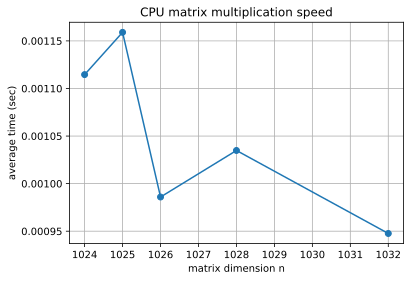

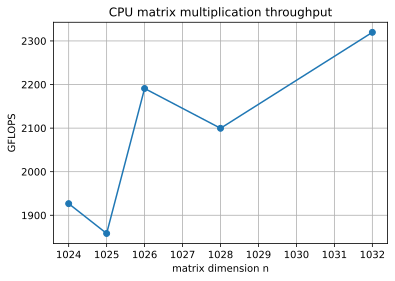

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(df["n"], df["avg_time_sec"], marker="o")
plt.xlabel("matrix dimension n")
plt.ylabel("average time (sec)")
plt.title("CPU matrix multiplication speed")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(df["n"], df["GFLOPS"], marker="o")
plt.xlabel("matrix dimension n")
plt.ylabel("GFLOPS")
plt.title("CPU matrix multiplication throughput")
plt.grid(True)
plt.show()

In [ ]:
# system_profiler SPHardwareDataType

### Exercise 8

Try out different activation functions. Which one works best?

In [24]:
class MLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr, activation):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens),
            activation,
            nn.LazyLinear(num_outputs)
        )

In [25]:
# disable D2L plotting
class MLPNoPlot(MLP):
    def plot(self, key, value, train):
        pass

In [26]:
def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            pred = y_hat.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total

In [27]:
activations = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'LeakyReLU': nn.LeakyReLU(),
    'GELU': nn.GELU()
}

results = []

for name, act in activations.items():
    print(f"Training with {name}...")

    model = MLPNoPlot(
        num_outputs=10,
        num_hiddens=256,
        lr=0.1,
        activation=act
    )
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)

    val_acc = evaluate_accuracy(model, data.val_dataloader())
    results.append((name, val_acc))
    print(f"{name}: val_acc = {val_acc:.4f}\n")

Training with ReLU...


/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


ReLU: val_acc = 0.8534

Training with Sigmoid...
Sigmoid: val_acc = 0.8131

Training with Tanh...
Tanh: val_acc = 0.8373

Training with LeakyReLU...
LeakyReLU: val_acc = 0.8345

Training with GELU...
GELU: val_acc = 0.8289



  activation  val_acc
0       ReLU   0.8534
2       Tanh   0.8373
3  LeakyReLU   0.8345
4       GELU   0.8289
1    Sigmoid   0.8131


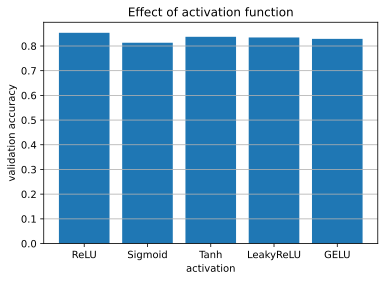

In [28]:
df = pd.DataFrame(results, columns=['activation', 'val_acc'])
print(df.sort_values('val_acc', ascending=False))

plt.figure(figsize=(6, 4))
plt.bar(df['activation'], df['val_acc'])
plt.xlabel('activation')
plt.ylabel('validation accuracy')
plt.title('Effect of activation function')
plt.grid(axis='y')
plt.show()